# SparseSensing Tutorial 05

This notebook compares the current `HOSVDBasis` implementation in RAVEN with flat snapshot SVD. The key caveat is that the current implementation extracts the **spatial factor** from the tensor's spatial unfolding, so it acts as a consistency check rather than a blanket claim that HOSVD is always better.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pysensors as ps
import importlib.util
from pathlib import Path

repo_root = Path.cwd().parent.parent
module_path = repo_root / 'ravenframework' / 'Models' / 'PostProcessors' / 'SparseSensingBases.py'
spec = importlib.util.spec_from_file_location('SparseSensingBases', module_path)
SparseSensingBases = importlib.util.module_from_spec(spec)
spec.loader.exec_module(SparseSensingBases)

HOSVDBasis = SparseSensingBases.HOSVDBasis

In [2]:
rng = np.random.RandomState(0)
alphas = np.linspace(0.1, 1.0, 5)
times = np.linspace(0.0, 1.0, 8)
x = np.linspace(0.0, 1.0, 20)

f_alpha = np.exp(-0.7 * alphas)
g_time = np.cos(np.pi * times)
h_space_1 = np.sin(3.0 * np.pi * x)
h_space_2 = np.cos(5.0 * np.pi * x)

T = (
    1.4 * np.einsum('p,t,x->ptx', f_alpha, g_time, h_space_1)
    + 0.6 * np.einsum('p,t,x->ptx', 1.0 + alphas, np.exp(-times), h_space_2)
    + 1e-3 * rng.randn(len(alphas), len(times), len(x))
)
snapshot_matrix = T.reshape(len(alphas) * len(times), len(x))
T.shape, snapshot_matrix.shape

((5, 8, 20), (40, 20))

Both bases below produce a spatial matrix with shape `(n_space, rank)`. Because `HOSVDBasis` uses the spatial unfolding `T.transpose(2, 0, 1).reshape(n_space, n_samples * n_time)`, it is closely related to the right singular vectors of the snapshot matrix.

In [3]:
def rel_projection_error(matrix, basis):
    return np.linalg.norm(matrix - matrix @ basis @ basis.T) / np.linalg.norm(matrix)

ranks = range(1, 7)
svd_err = []
hosvd_err = []
basis_gap = []

for r in ranks:
    svd_basis = ps.basis.SVD(n_basis_modes=r).fit(snapshot_matrix).basis_matrix_
    hosvd_basis = HOSVDBasis(n_basis_modes=r).fit(T).basis_matrix_
    svd_err.append(rel_projection_error(snapshot_matrix, svd_basis))
    hosvd_err.append(rel_projection_error(snapshot_matrix, hosvd_basis))
    basis_gap.append(np.linalg.norm(svd_basis @ svd_basis.T - hosvd_basis @ hosvd_basis.T))

svd_err, hosvd_err, basis_gap

([np.float64(0.5938631978731139),
  np.float64(0.0013368123881491506),
  np.float64(0.001242422813418867),
  np.float64(0.001156561233603798),
  np.float64(0.0010794931390923205),
  np.float64(0.0010068125498160056)],
 [np.float64(0.5938631978731139),
  np.float64(0.00133681238814915),
  np.float64(0.001242422801146542),
  np.float64(0.001156561230981906),
  np.float64(0.0010794931385424227),
  np.float64(0.0010068125376890603)],
 [np.float64(7.304332554641554e-16),
  np.float64(1.3502196801554164e-15),
  np.float64(0.0005851053884747636),
  np.float64(0.0002569219570061729),
  np.float64(0.00013188274877542772),
  np.float64(0.0006632964205790918)])

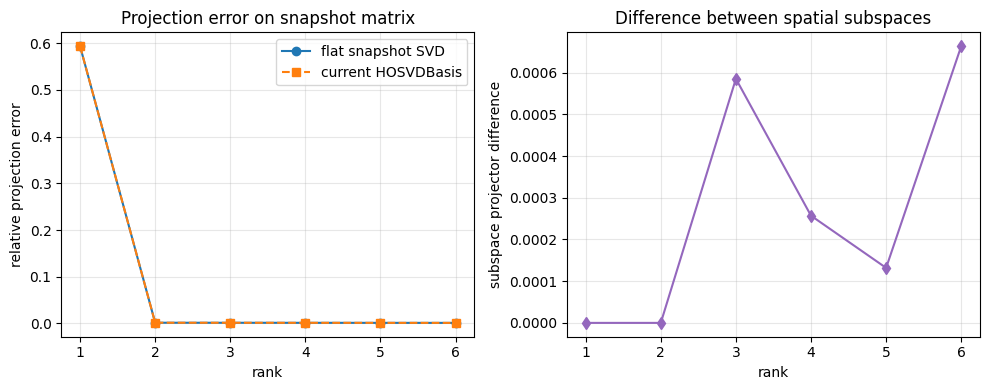

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(list(ranks), svd_err, 'o-', label='flat snapshot SVD')
axes[0].plot(list(ranks), hosvd_err, 's--', label='current HOSVDBasis')
axes[0].set_xlabel('rank')
axes[0].set_ylabel('relative projection error')
axes[0].set_title('Projection error on snapshot matrix')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(list(ranks), basis_gap, 'd-', color='tab:purple')
axes[1].set_xlabel('rank')
axes[1].set_ylabel('subspace projector difference')
axes[1].set_title('Difference between spatial subspaces')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

On this implementation, the two curves should be very close and the subspace difference should be near zero. That is the expected result: the current `HOSVDBasis` is effectively extracting the same spatial singular subspace that flat snapshot SVD sees through the reshaped matrix. The notebook is therefore a **sanity check of the implementation**, not evidence that HOSVD always dominates SVD.